<a href="https://colab.research.google.com/github/Fardous-bp/CNS-doped-Al-interconnect-alloy/blob/main/CNS_Al_12_5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install matcalc

!pip install matgl
!pip install seekpath

!pip install crystal-toolkit

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 579.9/579.9 kB 10.0 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.8 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.0/3.0 MB 66.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 598.8/598.8 kB 38.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 850.5/850.5 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 829.1/829.1 kB 47.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 70.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.6/4.6 MB 110.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 962.5/962.5 kB 50.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 114.9/114.9 kB 11.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━

In [ ]:
import os
from pymatgen.core import Structure
my_cif_file = "CuNi2Sn.cif"

if os.path.exists(my_cif_file):
    my_structure = Structure.from_file(my_cif_file)
    print(f"SUCCESS: {my_cif_file} loaded successfully.")
    print(my_structure)
else:
    print(f"ERROR: File '{my_cif_file}' not found. Please check the name in your Colab files tab.")

SUCCESS: CuNi2Sn.cif loaded successfully.
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.975124   5.975124   5.975124
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP       a     b     c
---  ----  ----  ----  ----
  0  Cu    0     0     0
  1  Cu    0     0.5   0.5
  2  Cu    0.5   0     0.5
  3  Cu    0.5   0.5   0
  4  Ni    0.25  0.75  0.75
  5  Ni    0.25  0.25  0.75
  6  Ni    0.25  0.25  0.25
  7  Ni    0.25  0.75  0.25
  8  Ni    0.75  0.75  0.25
  9  Ni    0.75  0.25  0.25
 10  Ni    0.75  0.25  0.75
 11  Ni    0.75  0.75  0.75
 12  Sn    0     0     0.5
 13  Sn    0     0.5   0
 14  Sn    0.5   0     0
 15  Sn    0.5   0.5   0.5


In [ ]:
# The value 0.2 adds random noise (in Angstroms) to the atomic sites
cuni2sn_perturbed = my_structure.copy()
cuni2sn_perturbed.perturb(0.2)

# 2. Expand the lattice volume
# Multiplying by 1.2 increases the total cell volume by 20%
cuni2sn_perturbed.scale_lattice(my_structure.volume * 1.2)

# 3. View the results
print("Perturbed CuNi2Sn Structure:")
print(cuni2sn_perturbed)
cuni2sn_perturbed

Perturbed CuNi2Sn Structure:
Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   6.349517   6.349517   6.349517
angles:  90.000000  90.000000  90.000000
pbc   :       True       True       True
Sites (16)
  #  SP           a         b         c
---  ----  --------  --------  --------
  0  Cu    0.008764  0.020937  0.999532
  1  Cu    0.992916  0.501041  0.503705
  2  Cu    0.497642  0.988628  0.494613
  3  Cu    0.522386  0.496183  0.007705
  4  Ni    0.256931  0.718659  0.750898
  5  Ni    0.243624  0.255024  0.753115
  6  Ni    0.254989  0.239708  0.257758
  7  Ni    0.240478  0.735057  0.244301
  8  Ni    0.76168   0.77234   0.231576
  9  Ni    0.755166  0.253217  0.247632
 10  Ni    0.741354  0.255219  0.759703
 11  Ni    0.763824  0.762295  0.731713
 12  Sn    0.002258  0.994051  0.511606
 13  Sn    0.023231  0.505103  0.980944
 14  Sn    0.500246  0.000602  0.00162
 15  Sn    0.502933  0.502481  0.499582


Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : 6.349516720528679 0.0 3.887957663964023e-16
      B : 1.0210801652782683e-15 6.349516720528679 3.887957663964023e-16
      C : 0.0 0.0 6.349516720528679
    pbc : True True True
PeriodicSite: Cu0 (Cu) (0.05565, 0.1329, 6.347) [0.008764, 0.02094, 0.9995]
PeriodicSite: Cu1 (Cu) (6.305, 3.181, 3.198) [0.9929, 0.501, 0.5037]
PeriodicSite: Cu2 (Cu) (3.16, 6.277, 3.141) [0.4976, 0.9886, 0.4946]
PeriodicSite: Cu3 (Cu) (3.317, 3.151, 0.04892) [0.5224, 0.4962, 0.007705]
PeriodicSite: Ni4 (Ni) (1.631, 4.563, 4.768) [0.2569, 0.7187, 0.7509]
PeriodicSite: Ni5 (Ni) (1.547, 1.619, 4.782) [0.2436, 0.255, 0.7531]
PeriodicSite: Ni6 (Ni) (1.619, 1.522, 1.637) [0.255, 0.2397, 0.2578]
PeriodicSite: Ni7 (Ni) (1.527, 4.667, 1.551) [0.2405, 0.7351, 0.2443]
PeriodicSite: Ni8 (Ni) (4.836, 4.904, 1.47) [0.7617, 0.7723, 0.2316]
PeriodicSite: Ni9 (Ni) (4.795, 1.

In [ ]:
import matcalc
from matcalc.utils import UNIVERSAL_CALCULATORS

import pprint
pprint.pprint(list(UNIVERSAL_CALCULATORS))  # calculators that come with bundled with matgl

[<UNIVERSAL_CALCULATORS.CHGNet-MatPES-PBE-2025.2.10: 'CHGNet-MatPES-PBE-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.CHGNet-MatPES-r2SCAN-2025.2.10: 'CHGNet-MatPES-r2SCAN-2025.2.10'>,
 <UNIVERSAL_CALCULATORS.DPA3-LAM-2025.3.14: 'DPA3-LAM-2025.3.14'>,
 <UNIVERSAL_CALCULATORS.GRACE-1L-OAM: 'GRACE-1L-OAM'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-MPtrj: 'GRACE-2L-MPtrj'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-OAM: 'GRACE-2L-OAM'>,
 <UNIVERSAL_CALCULATORS.GRACE-2L-OMAT: 'GRACE-2L-OMAT'>,
 <UNIVERSAL_CALCULATORS.M3GNet-MatPES-PBE-2025.1: 'M3GNet-MatPES-PBE-2025.1'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-large: 'MACE-MP-0-large'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-medium: 'MACE-MP-0-medium'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0-small: 'MACE-MP-0-small'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b-medium: 'MACE-MP-0b-medium'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b-small: 'MACE-MP-0b-small'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b2-large: 'MACE-MP-0b2-large'>,
 <UNIVERSAL_CALCULATORS.MACE-MP-0b2-medium: 'MACE-MP-0b2-medium'>,
 <UNIVE

In [ ]:
from matcalc.utils import MODEL_ALIASES
pprint.pprint(MODEL_ALIASES)  # list all "aliased" models

{'chgnet': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-matpes-pbe-2025.2.10-2.7m-pes': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-pes-matpes-pbe-2025.2.10': 'CHGNet-MatPES-PBE-2025.2.10',
 'chgnet-pes-matpes-r2scan-2025.2.10': 'CHGNet-MatPES-r2SCAN-2025.2.10',
 'deepmd': 'DPA3-LAM-2025.3.14',
 'fairchem': 'UMA-S-1.2',
 'grace': 'GRACE-2L-OAM',
 'm3gnet': 'M3GNet-MatPES-PBE-2025.1',
 'm3gnet-pes-matpes-pbe-2025.1': 'M3GNet-MatPES-PBE-2025.1',
 'mace': 'MACE-MPA-0-medium',
 'mattersim': 'MatterSim-v1.0.0-1M',
 'orb': 'ORB-v2',
 'pbe': 'TensorNet-MatPES-PBE-2025.2',
 'petmad': 'PETMAD-1.0.0',
 'r2scan': 'TensorNet-MatPES-r2SCAN-2025.2',
 'sevennet': 'SevenNet-0',
 'tensornet': 'TensorNet-MatPES-PBE-2025.2',
 'tensornet-pes-matpes-pbe-2025.2': 'TensorNet-MatPES-PBE-2025.2',
 'tensornet-pes-matpes-r2scan-2025.2': 'TensorNet-MatPES-r2SCAN-2025.2',
 'tensorpotential': 'GRACE-2L-OAM',
 'uma': 'UMA-S-1.2'}


In [ ]:
calculator_pbe = matcalc.load_fp("pbe")

model.pt: reconstructing file:   0%|          |  0.00B / 4.50kB            

model.pt: downloading bytes:           |  0.00B            

state.pt: reconstructing file:   0%|          |  0.00B / 3.40MB            

state.pt: downloading bytes:           |  0.00B            

model.json:   0%|          | 0.00/5.30k [00:00<?, ?B/s]

In [ ]:
# Initialize the Relaxer exactly like the notebook
relax_calc = matcalc.RelaxCalc(
    calculator_pbe,
    optimizer="FIRE",
    relax_atoms=True,
    relax_cell=True,
)

# This should now complete in 1-3 minutes
print("Starting structural optimization...")
data = relax_calc.calc(cuni2sn_perturbed)

# Output results
print(f"Optimization Successful!")
print(f"Final Energy: {data['energy']:.4f} eV")
print(f"Final Optimized Volume: {data['final_structure'].volume:.2f} A^3")

Starting structural optimization...
Optimization Successful!
Final Energy: -75.9541 eV
Final Optimized Volume: 214.28 A^3


In [ ]:
pprint.pprint(data)

{'_units': {'a': 'A',
            'alpha': 'degree',
            'b': 'A',
            'beta': 'degree',
            'c': 'A',
            'energy': 'eV',
            'final_structure': Structure Summary
Lattice
    abc : 6.349516720528679 6.349516720528679 6.349516720528679
 angles : 90.0 90.0 90.0
 volume : 255.98941833973996
      A : 6.349516720528679 0.0 3.887957663964023e-16
      B : 1.0210801652782683e-15 6.349516720528679 3.887957663964023e-16
      C : 0.0 0.0 6.349516720528679
    pbc : True True True
PeriodicSite: Cu0 (Cu) (0.05565, 0.1329, 6.347) [0.008764, 0.02094, 0.9995]
PeriodicSite: Cu1 (Cu) (6.305, 3.181, 3.198) [0.9929, 0.501, 0.5037]
PeriodicSite: Cu2 (Cu) (3.16, 6.277, 3.141) [0.4976, 0.9886, 0.4946]
PeriodicSite: Cu3 (Cu) (3.317, 3.151, 0.04892) [0.5224, 0.4962, 0.007705]
PeriodicSite: Ni4 (Ni) (1.631, 4.563, 4.768) [0.2569, 0.7187, 0.7509]
PeriodicSite: Ni5 (Ni) (1.547, 1.619, 4.782) [0.2436, 0.255, 0.7531]
PeriodicSite: Ni6 (Ni) (1.619, 1.522, 1.637) [0.255, 0.

In [ ]:
final_structure_pbe = data["final_structure"]
print(final_structure_pbe)
final_structure_pbe

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.984805   5.983906   5.983479
angles:  89.997628  90.064389  89.956336
pbc   :       True       True       True
Sites (16)
  #  SP           a          b          c
---  ----  --------  ---------  ---------
  0  Cu    0.009007   0.002816   0.994508
  1  Cu    0.999628   0.499413   0.499345
  2  Cu    0.501781   0.997145   0.497817
  3  Cu    0.506553   0.500774   0.002732
  4  Ni    0.255809   0.742837   0.748263
  5  Ni    0.260372   0.257294   0.74476
  6  Ni    0.253113   0.252701   0.252006
  7  Ni    0.24814    0.747467   0.24877
  8  Ni    0.760416   0.757112   0.244892
  9  Ni    0.755803   0.243016   0.248384
 10  Ni    0.748298   0.247355   0.748733
 11  Ni    0.752973   0.752655   0.75212
 12  Sn    0.007245   1.00106    0.503283
 13  Sn    0.00078    0.49623    0.997823
 14  Sn    0.498183  -0.000658  -0.000597
 15  Sn    0.510323   0.503333   0.493163


Structure Summary
Lattice
    abc : 5.984805130536414 5.983906486274082 5.983478687210954
 angles : 89.9976280506476 90.06438856736732 89.95633581845038
 volume : 214.2832179623092
      A : 5.984803750830285 0.0022808155693173644 -0.003363394576615327
      B : 0.0022798347352824032 5.983906050683518 0.00012417643351583563
      C : -0.003361586809485676 0.00012481921902124615 5.9834777416200025
    pbc : True True True
PeriodicSite: Cu (0.05057, 0.017, 5.951) [0.009007, 0.002816, 0.9945]
PeriodicSite: Cu (5.982, 2.991, 2.985) [0.9996, 0.4994, 0.4993]
PeriodicSite: Cu (3.004, 5.968, 2.977) [0.5018, 0.9971, 0.4978]
PeriodicSite: Cu (3.033, 2.998, 0.01471) [0.5066, 0.5008, 0.002732]
PeriodicSite: Ni (1.53, 4.446, 4.476) [0.2558, 0.7428, 0.7483]
PeriodicSite: Ni (1.556, 1.54, 4.455) [0.2604, 0.2573, 0.7448]
PeriodicSite: Ni (1.515, 1.513, 1.507) [0.2531, 0.2527, 0.252]
PeriodicSite: Ni (1.486, 4.473, 1.488) [0.2481, 0.7475, 0.2488]
PeriodicSite: Ni (4.552, 4.532, 1.463) [0.7604, 0.7571, 

In [ ]:
from matcalc import ElasticityCalc

# Use the 'final_structure_pbe' generated
multiplier_GPa = 160.2176621
elastic_calc = ElasticityCalc(calculator_pbe, relax_structure=False)
elastic_results = elastic_calc.calc(final_structure_pbe)

print(f"Bulk Modulus: {elastic_results['bulk_modulus_vrh'] * multiplier_GPa:.2f} GPa")
print(f"Shear Modulus: {elastic_results['shear_modulus_vrh'] * multiplier_GPa:.2f} GPa")

Bulk Modulus: 142.80 GPa
Shear Modulus: 37.69 GPa


/tmp/ipykernel_1705/73195017.py:6: RuntimeWarning: Elastic strain-stress fits have mean R²=0.7080 below r2_min=0.95. The elastic tensor may be unreliable; consider smaller |strains|, more strain points, or enabling relax_deformed_structures.
  elastic_results = elastic_calc.calc(final_structure_pbe)


/usr/local/lib/python3.13/dist-packages/matcalc/_phonon.py:214: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000,  0.00000,  1.00000]
  [-0.00000, -1.00000,  0.00000]
  [ 1.00000, -0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


Calculating Phonon Data for Pure CuNi2Sn...


/tmp/ipykernel_1705/1823654510.py:24: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos_dict = ph.get_total_dos_dict()


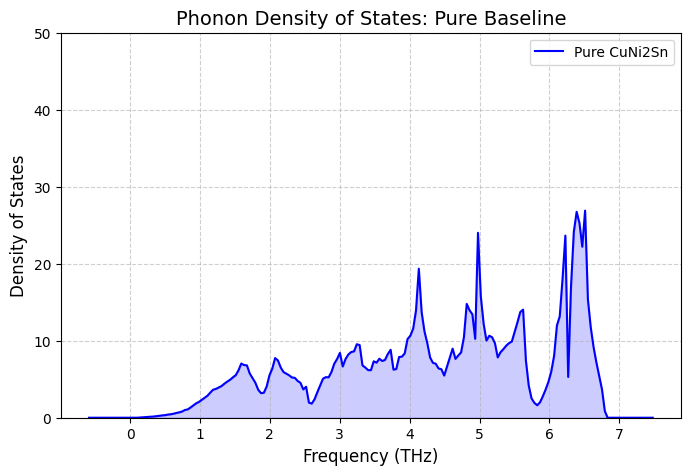

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt

# 1. Initialize for the pure structure
phonon_calc = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for Pure CuNi2Sn...")
pure_phonon_data = phonon_calc.calc(final_structure_pbe)

# 2. Access the Phonopy object
ph = pure_phonon_data["phonon"]

# 3. Trigger the DOS calculation (Fixes the AttributeError)
# We use a mesh of 20x20x20 for resolution
ph.run_mesh([20, 20, 20])
ph.run_total_dos()

# 4. Extract frequencies and densities
# get_total_dos_dict() returns a dictionary with 'frequency-points' and 'total-dos'
dos_dict = ph.get_total_dos_dict()
freqs = dos_dict['frequency_points']
densities = dos_dict['total_dos']

# 5. Visualization for Paper
plt.figure(figsize=(8, 5))
plt.plot(freqs, densities, color='blue', label='Pure CuNi2Sn')
plt.fill_between(freqs, densities, color='blue', alpha=0.2)
plt.ylim(0, 50)
plt.title("Phonon Density of States: Pure Baseline", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

In [ ]:
# 1. Second 'Doped' version from the pure optimized structure
sac_al_12_5 = final_structure_pbe.copy()

# 2. Replace TWO sites with Aluminum to achieve 12.5% doping (2/16 atoms)
# We use site 12 (Sn) and site 0 (Cu) for a balanced distribution
sac_al_12_5.replace(12, "Al")
sac_al_12_5.replace(0, "Al")

print(f"Created 12.5% Al-doped structure: {sac_al_12_5.formula}")

# 3. Proceed to High-Precision Relaxation
print("Starting high-precision optimization for 12.5% Al...")
relax_results_12_5 = relax_calc.calc(sac_al_12_5)
opt_struct_12_5 = relax_results_12_5["final_structure"]

print(f"12.5% Optimized Energy: {relax_results_12_5['energy']:.4f} eV")

# 4. Calculate Elastic Moduli
elastic_results_12_5 = elastic_calc.calc(opt_struct_12_5)
multiplier_GPa = 160.2176621

bulk_12_5 = elastic_results_12_5['bulk_modulus_vrh'] * multiplier_GPa
shear_12_5 = elastic_results_12_5['shear_modulus_vrh'] * multiplier_GPa

print(f"--- 12.5% Al Doping Results ---")
print(f"Bulk Modulus: {bulk_12_5:.2f} GPa")
print(f"Shear Modulus: {shear_12_5:.2f} GPa")

Created 12.5% Al-doped structure: Al2 Cu3 Ni8 Sn3
Starting high-precision optimization for 12.5% Al...
12.5% Optimized Energy: -77.7079 eV
--- 12.5% Al Doping Results ---
Bulk Modulus: 136.67 GPa
Shear Modulus: 43.47 GPa


/tmp/ipykernel_1705/297508440.py:19: RuntimeWarning: Elastic strain-stress fits have mean R²=0.6928 below r2_min=0.95. The elastic tensor may be unreliable; consider smaller |strains|, more strain points, or enabling relax_deformed_structures.
  elastic_results_12_5 = elastic_calc.calc(opt_struct_12_5)


/usr/local/lib/python3.13/dist-packages/matcalc/_phonon.py:214: PrimitiveMatrixAutoDefaultWarning: primitive_matrix defaulted to 'auto' and was resolved to a non-identity matrix:
  [ 0.00000, -0.00000,  1.00000]
  [ 0.00000,  1.00000, -0.00000]
  [-1.00000,  0.00000, -0.00000]
This differs from phonopy v3, whose default was the identity matrix. Pass primitive_matrix='P' (or --pa P on the command line) to restore the v3 behaviour.
  phonon = phonopy.Phonopy(cell, supercell_matrix=supercell_matrix, symprec=self.symprec, primitive_matrix="auto")


Calculating Phonon Data for 12.5% Al-Doped structure...


/tmp/ipykernel_1705/1459734092.py:21: DeprecationWarning: get_total_dos_dict() is deprecated. Use the total_dos property to access the TotalDos result object; its frequency_points and dos attributes replace the dict keys.
  dos_dict_12_5 = ph_12_5.get_total_dos_dict()


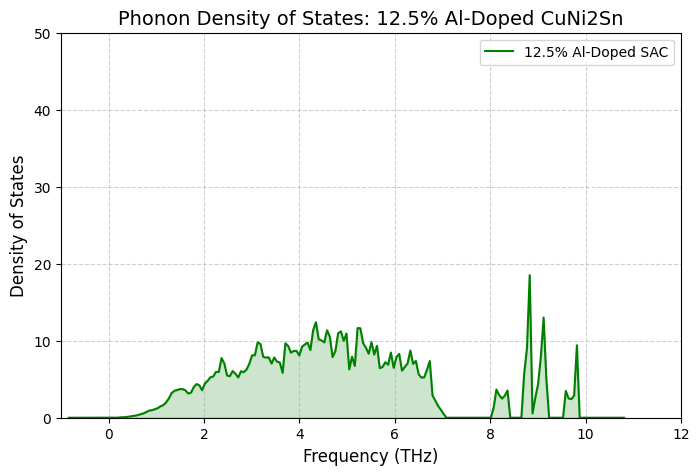

In [ ]:
from matcalc import PhononCalc
import matplotlib.pyplot as plt
import numpy as np

# 1. Initialize Phonon Calculator for 12.5%
# Using the same supercell settings for a fair comparison
phonon_calc_12_5 = PhononCalc(
    calculator_pbe,
    supercell_matrix=((2, 0, 0), (0, 2, 0), (0, 0, 2)),
    relax_structure=False
)

print("Calculating Phonon Data for 12.5% Al-Doped structure...")
phonon_data_12_5 = phonon_calc_12_5.calc(opt_struct_12_5)
ph_12_5 = phonon_data_12_5["phonon"]

# 2. Run high-resolution DOS
ph_12_5.run_mesh([20, 20, 20])
ph_12_5.run_total_dos()

dos_dict_12_5 = ph_12_5.get_total_dos_dict()
freqs_12_5 = dos_dict_12_5['frequency_points']
densities_12_5 = dos_dict_12_5['total_dos']

# 3. Visualization
plt.figure(figsize=(8, 5))
plt.plot(freqs_12_5, densities_12_5, color='green', label='12.5% Al-Doped SAC')
plt.fill_between(freqs_12_5, densities_12_5, color='green', alpha=0.2)

# Set Y-axis range to 0-50 for consistent comparison
plt.ylim(0, 50)
plt.xlim(-1, 12)

plt.title("Phonon Density of States: 12.5% Al-Doped CuNi2Sn", fontsize=14)
plt.xlabel("Frequency (THz)", fontsize=12)
plt.ylabel("Density of States", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


In [ ]:
# 4. Extract Thermodynamic Stability at Harsh Environment (473K)
ph_12_5.run_thermal_properties(t_step=5, t_max=600, t_min=0)
tp_12_5 = ph_12_5.get_thermal_properties_dict()

num_atoms = 16

# Use np to find the index closest to your target temperature (473K)
idx_473 = (np.abs(tp_12_5['temperatures'] - 473)).argmin()

# Apply the normalization factor to the target indexed outputs
normalized_free_energy = tp_12_5['free_energy'][idx_473] / num_atoms
normalized_entropy = tp_12_5['entropy'][idx_473] / num_atoms

print(f"--- 12.5% Al THERMODYNAMICS (NORMALIZED PER ATOM) ---")
print(f"Free Energy at 473K: {normalized_free_energy:.4f} kJ/mol·atom")
print(f"Entropy at 473K: {normalized_entropy:.4f} J/K/mol·atom")

--- 12.5% Al THERMODYNAMICS (NORMALIZED PER ATOM) ---
Free Energy at 473K: -9.6158 kJ/mol·atom
Entropy at 473K: 45.7706 J/K/mol·atom


/tmp/ipykernel_1705/1775560834.py:3: DeprecationWarning: get_thermal_properties_dict() is deprecated. Use the thermal_properties property to access the ThermalProperties result object; its temperatures, free_energy, entropy, and heat_capacity attributes replace the dict keys.
  tp_12_5 = ph_12_5.get_thermal_properties_dict()


In [ ]:
print(final_structure_pbe)
print("Number of atoms:", len(final_structure_pbe))
print("Formula:", final_structure_pbe.formula)
print("Volume:", final_structure_pbe.volume)

Full Formula (Cu4 Ni8 Sn4)
Reduced Formula: CuNi2Sn
abc   :   5.984805   5.983906   5.983479
angles:  89.997628  90.064389  89.956336
pbc   :       True       True       True
Sites (16)
  #  SP           a          b          c
---  ----  --------  ---------  ---------
  0  Cu    0.009007   0.002816   0.994508
  1  Cu    0.999628   0.499413   0.499345
  2  Cu    0.501781   0.997145   0.497817
  3  Cu    0.506553   0.500774   0.002732
  4  Ni    0.255809   0.742837   0.748263
  5  Ni    0.260372   0.257294   0.74476
  6  Ni    0.253113   0.252701   0.252006
  7  Ni    0.24814    0.747467   0.24877
  8  Ni    0.760416   0.757112   0.244892
  9  Ni    0.755803   0.243016   0.248384
 10  Ni    0.748298   0.247355   0.748733
 11  Ni    0.752973   0.752655   0.75212
 12  Sn    0.007245   1.00106    0.503283
 13  Sn    0.00078    0.49623    0.997823
 14  Sn    0.498183  -0.000658  -0.000597
 15  Sn    0.510323   0.503333   0.493163
Number of atoms: 16
Formula: Cu4 Ni8 Sn4
Volume: 214.28321796

In [ ]:
final_structure_pbe.to(filename="CuNi2Sn_12.5Al_relaxed.cif")

"# generated using pymatgen\ndata_CuNi2Sn\n_symmetry_space_group_name_H-M   'P 1'\n_cell_length_a   5.98480513\n_cell_length_b   5.98390649\n_cell_length_c   5.98347869\n_cell_angle_alpha   89.99762805\n_cell_angle_beta   90.06438857\n_cell_angle_gamma   89.95633582\n_symmetry_Int_Tables_number   1\n_chemical_formula_structural   CuNi2Sn\n_chemical_formula_sum   'Cu4 Ni8 Sn4'\n_cell_volume   214.28321796\n_cell_formula_units_Z   4\nloop_\n _symmetry_equiv_pos_site_id\n _symmetry_equiv_pos_as_xyz\n  1  'x, y, z'\nloop_\n _atom_site_type_symbol\n _atom_site_label\n _atom_site_symmetry_multiplicity\n _atom_site_fract_x\n _atom_site_fract_y\n _atom_site_fract_z\n _atom_site_occupancy\n  Cu  Cu0  1  0.00900725  0.00281606  0.99450801  1\n  Cu  Cu1  1  0.99962822  0.49941303  0.49934481  1\n  Cu  Cu2  1  0.50178075  0.99714500  0.49781702  1\n  Cu  Cu3  1  0.50655272  0.50077374  0.00273233  1\n  Ni  Ni4  1  0.25580906  0.74283700  0.74826330  1\n  Ni  Ni5  1  0.26037184  0.25729435  0.74475

In [ ]:
[v for v in globals() if "12" in v.lower() or "125" in v.lower()]

['_i12',
 'sac_al_12_5',
 'relax_results_12_5',
 'opt_struct_12_5',
 'elastic_results_12_5',
 'bulk_12_5',
 'shear_12_5',
 'phonon_calc_12_5',
 'phonon_data_12_5',
 'ph_12_5',
 'dos_dict_12_5',
 'freqs_12_5',
 'densities_12_5',
 'tp_12_5']

In [ ]:
print(opt_struct_12_5)

print("Number of atoms:", len(opt_struct_12_5))

print("Formula:", opt_struct_12_5.formula)

print("Volume:", opt_struct_12_5.volume)

Full Formula (Al2 Cu3 Ni8 Sn3)
Reduced Formula: Al2Cu3Ni8Sn3
abc   :   5.961265   5.960316   5.945593
angles:  90.000073  90.038593  89.970070
pbc   :       True       True       True
Sites (16)
  #  SP           a          b          c
---  ----  --------  ---------  ---------
  0  Al    0.006558   0.001435   0.996029
  1  Cu    1.0012     0.499617   0.499066
  2  Cu    0.502174   0.998196   0.497775
  3  Cu    0.505601   0.500336   0.000524
  4  Ni    0.241618   0.759841   0.742926
  5  Ni    0.243929   0.240282   0.741516
  6  Ni    0.240115   0.238121   0.255512
  7  Ni    0.237987   0.761994   0.254106
  8  Ni    0.770826   0.767026   0.253406
  9  Ni    0.768625   0.233175   0.254743
 10  Ni    0.76485    0.234955   0.742183
 11  Ni    0.767254   0.765251   0.743524
 12  Al    0.006794   1.00062    0.50114
 13  Sn    0.001899   0.498778   0.998118
 14  Sn    0.502343  -0.000486  -0.000518
 15  Sn    0.506656   0.501409   0.495952
Number of atoms: 16
Formula: Al2 Cu3 Ni8 Sn3
Volum

In [ ]:
from pymatgen.io.ase import AseAtomsAdaptor
from ase.io import write

# Convert the relaxed 12.5 at.% Al structure to ASE
atoms_12_5 = AseAtomsAdaptor.get_atoms(opt_struct_12_5)

# Attach the exact same TensorNet-MatPES-PBE calculator
atoms_12_5.calc = calculator_pbe

print("Original structure:")
print("Number of atoms:", len(atoms_12_5))
print("Formula:", atoms_12_5.get_chemical_formula())
print("PBC:", atoms_12_5.get_pbc())

# Create 2 × 2 × 2 supercell
atoms_super_12_5 = atoms_12_5.copy()
atoms_super_12_5 *= (2, 2, 2)

# Re-attach calculator after replication
atoms_super_12_5.calc = calculator_pbe

print("\n2 × 2 × 2 supercell:")
print("Number of atoms:", len(atoms_super_12_5))
print("Formula:", atoms_super_12_5.get_chemical_formula())
print("PBC:", atoms_super_12_5.get_pbc())
print("Cell:")
print(atoms_super_12_5.cell)

# Save relaxed supercell
write(
    "CuNi2Sn_12.5Al_2x2x2_relaxed.cif",
    atoms_super_12_5
)

Original structure:
Number of atoms: 16
Formula: Al2Cu3Ni8Sn3
PBC: [ True  True  True]

2 × 2 × 2 supercell:
Number of atoms: 128
Formula: Al16Cu24Ni64Sn24
PBC: [ True  True  True]
Cell:
Cell([[11.922528864366116, 0.00311470061983979, -0.0040029406305301055], [0.0031129063785549343, 11.920631396735061, -7.99566968681197e-06], [-0.004017180431401588, -6.125429675554259e-06, 11.89118480419259]])


In [32]:
# =========================================================
# Reproducible NVT MD — 12.5 at.% Al
# Three independent replicas: seeds 2001, 2002, 2003
# =========================================================
from ase import units
from ase.md.langevin import Langevin
from ase.md.velocitydistribution import MaxwellBoltzmannDistribution, Stationary
from ase.md import MDLogger
from ase.io import Trajectory
import numpy as np
import time
import os

temperature_K = 473
timestep = 1.0 * units.fs
friction = 0.01 / units.fs
nsteps = 2000
save_interval = 10

seeds = [2001, 2002, 2003]

for seed in seeds:
    print("\n" + "="*60)
    print(f"Starting 12.5 at.% Al MD — seed {seed}")
    print("="*60)

    # Fresh copy for each independent replica
    md_atoms_12_5 = atoms_super_12_5.copy()
    md_atoms_12_5.calc = calculator_pbe

    # Reproducible initial velocities and Langevin noise
    rng = np.random.RandomState(seed)
    MaxwellBoltzmannDistribution(
        md_atoms_12_5,
        temperature_K=temperature_K,
        rng=rng
    )
    Stationary(md_atoms_12_5)

    dyn = Langevin(
        md_atoms_12_5,
        timestep,
        temperature_K=temperature_K,
        friction=friction,
        fixcm=False,
        rng=rng
    )

    traj_file = f"CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed{seed}.traj"
    log_file = f"CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed{seed}.log"

    traj = Trajectory(traj_file, "w", md_atoms_12_5)

    logger = MDLogger(
        dyn,
        md_atoms_12_5,
        log_file,
        header=True,
        stress=False,
        peratom=False,
        mode="w"
    )

    dyn.attach(traj.write, interval=save_interval)
    dyn.attach(logger, interval=save_interval)

    start = time.time()
    dyn.run(nsteps)
    elapsed = time.time() - start

    traj.close()

    print("MD completed.")
    print(f"Seed: {seed}")
    print(f"Runtime: {elapsed/60:.2f} minutes")
    print(f"Time per step: {elapsed/nsteps:.4f} s")
    print(f"Trajectory: {traj_file}")
    print(f"Log: {log_file}")


/tmp/ipykernel_1705/2421617709.py:33: DeprecationWarning: Use thermalize_momenta
  MaxwellBoltzmannDistribution(



Starting 12.5 at.% Al MD — seed 2001
MD completed.
Seed: 2001
Runtime: 31.34 minutes
Time per step: 0.9401 s
Trajectory: CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed2001.traj
Log: CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed2001.log

Starting 12.5 at.% Al MD — seed 2002
MD completed.
Seed: 2002
Runtime: 31.57 minutes
Time per step: 0.9471 s
Trajectory: CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed2002.traj
Log: CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed2002.log

Starting 12.5 at.% Al MD — seed 2003
MD completed.
Seed: 2003
Runtime: 31.45 minutes
Time per step: 0.9434 s
Trajectory: CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed2003.traj
Log: CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed2003.log


In [33]:
# =========================================================
# Inspect all three MD trajectories
# =========================================================
from ase.io import Trajectory
import numpy as np
import os

seeds = [2001, 2002, 2003]

for seed in seeds:
    traj_file = f"CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed{seed}.traj"
    traj = Trajectory(traj_file)

    temps = []
    potential_energies = []

    for atoms in traj:
        temps.append(atoms.get_temperature())
        potential_energies.append(atoms.get_potential_energy())

    temps = np.array(temps)
    potential_energies = np.array(potential_energies)

    print("\n" + "="*60)
    print(f"12.5 at.% Al — seed {seed}")
    print("="*60)
    print("Frames:", len(traj))
    print("Atoms/frame:", len(traj[0]))
    print("Total simulation time:", (len(traj)-1)*save_interval/1000, "ps")

    print("\nTemperature:")
    print(f"Mean: {temps.mean():.4f} K")
    print(f"Std:  {temps.std():.4f} K")
    print(f"Min:  {temps.min():.4f} K")
    print(f"Max:  {temps.max():.4f} K")

    print("\nPotential energy:")
    print(f"Initial: {potential_energies[0]:.6f} eV")
    print(f"Final:   {potential_energies[-1]:.6f} eV")
    print(f"Minimum: {potential_energies.min():.6f} eV")
    print(f"Maximum: {potential_energies.max():.6f} eV")



12.5 at.% Al — seed 2001
Frames: 201
Atoms/frame: 128
Total simulation time: 2.0 ps

Temperature:
Mean: 469.0480 K
Std:  44.8453 K
Min:  224.9604 K
Max:  573.3636 K

Potential energy:
Initial: -621.662903 eV
Final:   -613.824829 eV
Minimum: -621.662903 eV
Maximum: -612.971130 eV

12.5 at.% Al — seed 2002
Frames: 201
Atoms/frame: 128
Total simulation time: 2.0 ps

Temperature:
Mean: 461.7479 K
Std:  47.5451 K
Min:  251.7006 K
Max:  574.1334 K

Potential energy:
Initial: -621.662903 eV
Final:   -614.786438 eV
Minimum: -621.662903 eV
Maximum: -612.784119 eV

12.5 at.% Al — seed 2003
Frames: 201
Atoms/frame: 128
Total simulation time: 2.0 ps

Temperature:
Mean: 458.0361 K
Std:  49.7586 K
Min:  244.7396 K
Max:  538.7268 K

Potential energy:
Initial: -621.662903 eV
Final:   -615.528137 eV
Minimum: -621.662903 eV
Maximum: -612.493469 eV



PBC-corrected MSD — 12.5 at.% Al, seed 2001
0.25 ps : 0.077075 Å²
0.50 ps : 0.080282 Å²
0.75 ps : 0.090132 Å²
1.00 ps : 0.091119 Å²
1.25 ps : 0.098212 Å²
1.50 ps : 0.099843 Å²
1.75 ps : 0.093739 Å²
2.00 ps : 0.060569 Å²

PBC-corrected MSD — 12.5 at.% Al, seed 2002
0.25 ps : 0.076026 Å²
0.50 ps : 0.082919 Å²
0.75 ps : 0.083330 Å²
1.00 ps : 0.082760 Å²
1.25 ps : 0.082748 Å²
1.50 ps : 0.080015 Å²
1.75 ps : 0.078653 Å²
2.00 ps : 0.051225 Å²

PBC-corrected MSD — 12.5 at.% Al, seed 2003
0.25 ps : 0.079871 Å²
0.50 ps : 0.083430 Å²
0.75 ps : 0.094398 Å²
1.00 ps : 0.096190 Å²
1.25 ps : 0.094705 Å²
1.50 ps : 0.081809 Å²
1.75 ps : 0.065335 Å²
2.00 ps : 0.040943 Å²


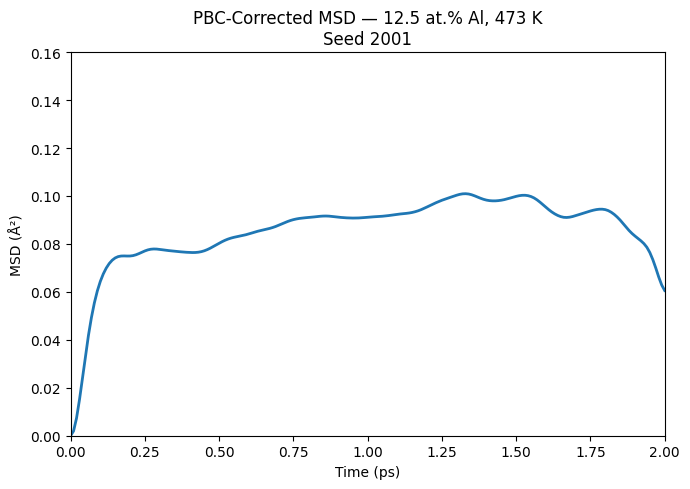

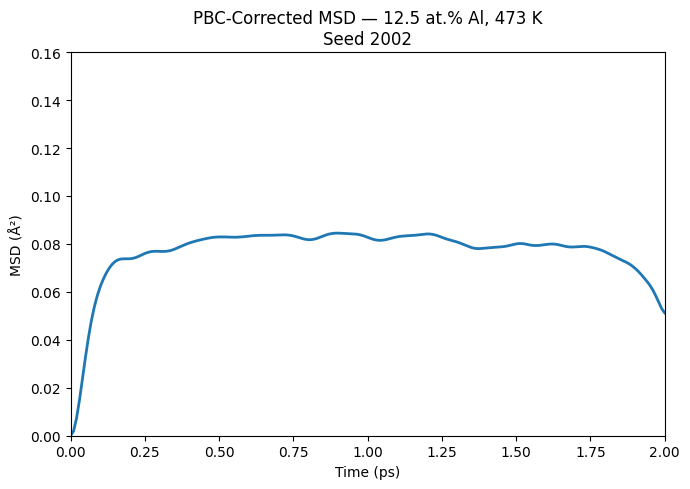

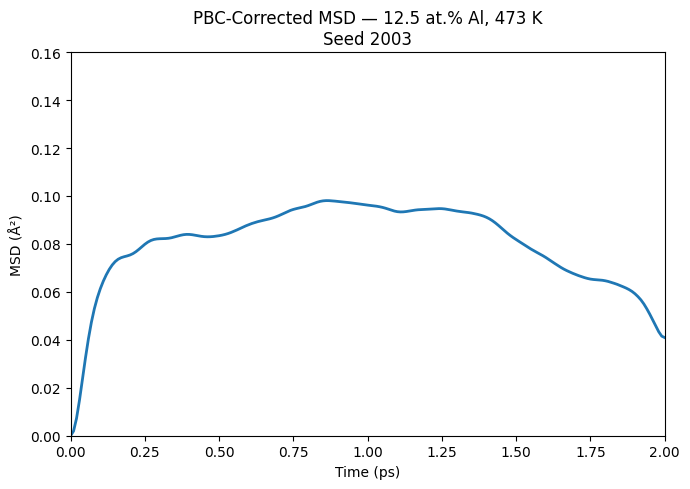

In [38]:
# =========================================================
# PBC-corrected, time-origin averaged MSD for all replicas
# =========================================================
from ase.io import Trajectory
import numpy as np
import matplotlib.pyplot as plt

seeds = [2001, 2002, 2003]
msd_results = {}

for seed in seeds:
    traj_file = f"CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed{seed}.traj"
    traj = Trajectory(traj_file)

    nframes = len(traj)
    natoms = len(traj[0])

    # Constant NVT cell
    cell = traj[0].get_cell().array

    # Wrapped fractional coordinates
    frac = np.array([
        atoms.get_scaled_positions(wrap=True)
        for atoms in traj
    ])

    # Explicit PBC unwrapping in fractional space
    unwrapped_frac = np.zeros_like(frac)
    unwrapped_frac[0] = frac[0]

    for t in range(1, nframes):
        delta = frac[t] - frac[t-1]
        delta -= np.round(delta)
        unwrapped_frac[t] = unwrapped_frac[t-1] + delta

    # Convert to Cartesian coordinates
    unwrapped_cart = np.einsum(
        "tni,ij->tnj",
        unwrapped_frac,
        cell
    )

    # Time-origin averaged MSD
    msd = np.zeros(nframes)

    for lag in range(1, nframes):
        displacement = (
            unwrapped_cart[lag:] -
            unwrapped_cart[:-lag]
        )
        squared_displacement = np.sum(
            displacement**2,
            axis=2
        )
        msd[lag] = np.mean(squared_displacement)

    time_ps = np.arange(nframes) * 0.01
    msd_results[seed] = (time_ps, msd)

    print("\n" + "="*60)
    print(f"PBC-corrected MSD — 12.5 at.% Al, seed {seed}")
    print("="*60)

    for ps in [
        0.25, 0.50, 0.75, 1.00,
        1.25, 1.50, 1.75, 2.00
    ]:
        idx = int(round(ps / 0.01))
        print(f"{ps:4.2f} ps : {msd[idx]:.6f} Å²")

# =========================================================
# Plot — one separate figure for each replica
# =========================================================

for seed in seeds:

    time_ps, msd = msd_results[seed]

    plt.figure(figsize=(7, 5))

    plt.plot(
        time_ps,
        msd,
        linewidth=2
    )

    plt.xlabel("Time (ps)")
    plt.ylabel("MSD (Å²)")

    plt.title(
        f"PBC-Corrected MSD — 12.5 at.% Al, 473 K\n"
        f"Seed {seed}"
    )

    plt.xlim(0, 2.0)
    plt.ylim(0, 0.16)

    plt.tight_layout()
    plt.show()



Species-resolved MSD — Seed 2001

Al:
0.25 ps : 0.068725 Å²
0.50 ps : 0.071757 Å²
0.75 ps : 0.084605 Å²
1.00 ps : 0.085931 Å²
1.25 ps : 0.093287 Å²
1.50 ps : 0.090257 Å²
1.75 ps : 0.092454 Å²

Cu:
0.25 ps : 0.076152 Å²
0.50 ps : 0.083807 Å²
0.75 ps : 0.089765 Å²
1.00 ps : 0.090896 Å²
1.25 ps : 0.100085 Å²
1.50 ps : 0.102334 Å²
1.75 ps : 0.095864 Å²

Ni:
0.25 ps : 0.085389 Å²
0.50 ps : 0.088707 Å²
0.75 ps : 0.099368 Å²
1.00 ps : 0.100505 Å²
1.25 ps : 0.108245 Å²
1.50 ps : 0.110205 Å²
1.75 ps : 0.102973 Å²

Sn:
0.25 ps : 0.061393 Å²
0.50 ps : 0.059973 Å²
0.75 ps : 0.069552 Å²
1.00 ps : 0.069773 Å²
1.25 ps : 0.072868 Å²
1.50 ps : 0.076111 Å²
1.75 ps : 0.067844 Å²

Species-resolved MSD — Seed 2002

Al:
0.25 ps : 0.064139 Å²
0.50 ps : 0.075722 Å²
0.75 ps : 0.074606 Å²
1.00 ps : 0.075066 Å²
1.25 ps : 0.070737 Å²
1.50 ps : 0.069943 Å²
1.75 ps : 0.071007 Å²

Cu:
0.25 ps : 0.077330 Å²
0.50 ps : 0.088226 Å²
0.75 ps : 0.088942 Å²
1.00 ps : 0.084937 Å²
1.25 ps : 0.090295 Å²
1.50 ps : 0.087961 Å²


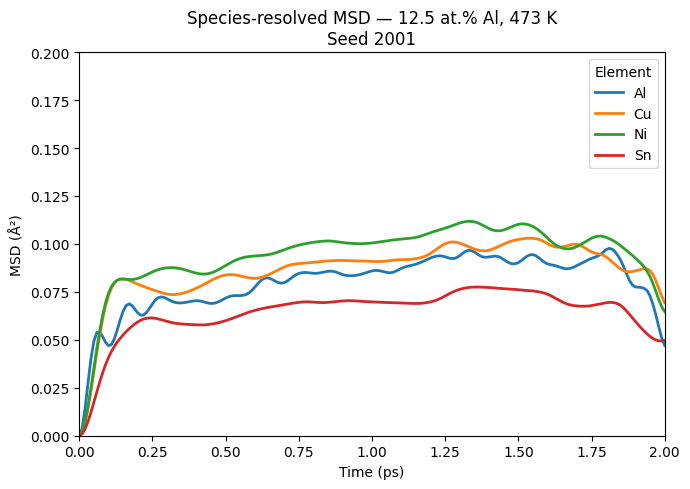

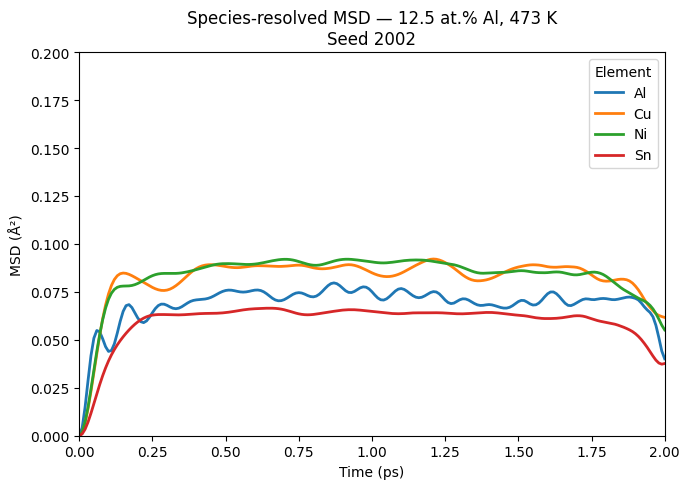

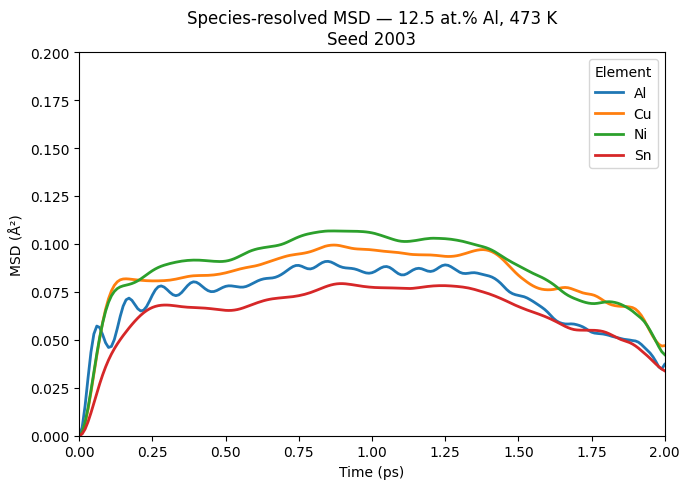

In [37]:
# =========================================================
# Species-resolved PBC-corrected MSD
# One figure per seed — all four elements in each figure
# =========================================================

from ase.io import Trajectory
import numpy as np
import matplotlib.pyplot as plt

seeds = [2001, 2002, 2003]
species_list = ["Al", "Cu", "Ni", "Sn"]

species_msd_results = {}

for seed in seeds:

    traj_file = f"CuNi2Sn_12.5Al_2x2x2_MD_2ps_seed{seed}.traj"
    traj = Trajectory(traj_file)

    nframes = len(traj)
    cell = traj[0].get_cell().array

    # -----------------------------------------------------
    # Fractional coordinates
    # -----------------------------------------------------
    frac = np.array([
        atoms.get_scaled_positions(wrap=True)
        for atoms in traj
    ])

    # -----------------------------------------------------
    # PBC unwrapping
    # -----------------------------------------------------
    unwrapped_frac = np.zeros_like(frac)
    unwrapped_frac[0] = frac[0]

    for t in range(1, nframes):
        delta = frac[t] - frac[t - 1]
        delta -= np.round(delta)
        unwrapped_frac[t] = unwrapped_frac[t - 1] + delta

    # -----------------------------------------------------
    # Convert fractional → Cartesian coordinates
    # -----------------------------------------------------
    unwrapped_cart = np.einsum(
        "tni,ij->tnj",
        unwrapped_frac,
        cell
    )

    symbols = np.array(
        traj[0].get_chemical_symbols()
    )

    species_msd = {}

    # -----------------------------------------------------
    # Calculate MSD for each element
    # -----------------------------------------------------
    for species in species_list:

        indices = np.where(symbols == species)[0]

        msd = np.zeros(nframes)

        for lag in range(1, nframes):

            displacement = (
                unwrapped_cart[lag:, indices, :]
                -
                unwrapped_cart[:-lag, indices, :]
            )

            squared_displacement = np.sum(
                displacement ** 2,
                axis=2
            )

            msd[lag] = np.mean(
                squared_displacement
            )

        species_msd[species] = msd

    # Time: trajectory saved every 10 fs = 0.01 ps
    time_ps = np.arange(nframes) * 0.01

    species_msd_results[seed] = (
        time_ps,
        species_msd
    )

    # -----------------------------------------------------
    # Print selected MSD values
    # -----------------------------------------------------
    print("\n" + "=" * 60)
    print(f"Species-resolved MSD — Seed {seed}")
    print("=" * 60)

    for species in species_list:

        print(f"\n{species}:")

        for ps in [
            0.25, 0.50, 0.75, 1.00,
            1.25, 1.50, 1.75
        ]:

            idx = int(round(ps / 0.01))

            print(
                f"{ps:4.2f} ps : "
                f"{species_msd[species][idx]:.6f} Å²"
            )


# =========================================================
# PLOT
# One figure per seed
# All four elements in each figure
# =========================================================

for seed in seeds:

    time_ps, species_msd = species_msd_results[seed]

    plt.figure(figsize=(7, 5))

    for species in species_list:

        plt.plot(
            time_ps,
            species_msd[species],
            linewidth=2,
            label=species
        )

    plt.xlabel("Time (ps)")
    plt.ylabel("MSD (Å²)")

    plt.title(
        f"Species-resolved MSD — 12.5 at.% Al, 473 K\n"
        f"Seed {seed}"
    )

    plt.xlim(0, 2.0)
    plt.ylim(0, 0.20)

    plt.legend(
        title="Element"
    )

    plt.tight_layout()
    plt.show()
